# Predicting Medical Insurance Charges with Multiple Linear Regression
**Dataset:** Medical Cost Personal Dataset (Lantz, 2013), 1,338 rows × 7 columns  
**Target variable:** `charges` (yearly medical insurance cost in USD)  
**Tools:** Python (pandas, matplotlib, seaborn, scikit-learn, statsmodels)

## 1. Setup and loading the data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")

# Load the dataset (insurance.csv must be in the same folder as this notebook)
df = pd.read_csv("insurance.csv")
df.head()


import os
print(os.getcwd())
print(os.listdir())
print(open("insurance.csv").readline())

/Users/shreyashipaul/insurance-project
['.DS_Store', 'insurance.csv', 'insurance_regression.ipynb', '.ipynb_checkpoints']
age,sex,bmi,children,smoker,region,charges



In [2]:
# Size and structure of the data
print("Shape:", df.shape)
df.info()

Shape: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
# Summary statistics for the numeric columns
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 2. Data quality check and cleaning

In [4]:
# Check for missing values in each column
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())
display(df[df.duplicated(keep=False)])

# Remove the duplicate and confirm the new size
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Shape after removing duplicates: (1337, 7)


In [6]:
# Check the categories in each text column for typos or inconsistent labels
for col in ["sex", "smoker", "region"]:
    print(col, "->", df[col].unique())

sex -> <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
region -> <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [7]:
# Check BMI for unrealistic values (healthy adult range is roughly 15-60)
print("BMI min:", df["bmi"].min(), "| BMI max:", df["bmi"].max())

BMI min: 15.96 | BMI max: 53.13


**Cleaning results:** The dataset has no missing values. One fully duplicated row was found and removed, leaving 1,337 rows. The categorical columns contain clean, consistent labels, and BMI ranges from about 16 to 53, which is realistic, so no BMI outliers were removed.

## 3. Exploratory data analysis

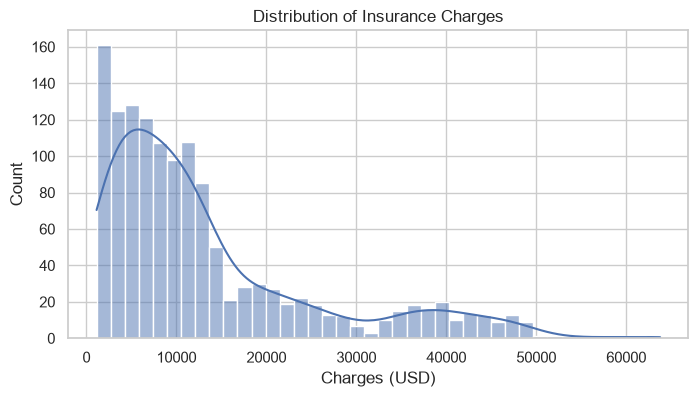

Skewness: 1.52


In [8]:
# Histogram of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df["charges"], bins=40, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges (USD)")
plt.show()
print("Skewness:", round(df["charges"].skew(), 2))

**Rationale and interpretation:** A histogram is the best first look at a continuous target because it shows its shape and spread. Charges are strongly right-skewed (skewness ≈ 1.5): most people pay under \$15,000, but a long tail reaches over \$60,000. This skew is why I will also test a log-transformed target in the modelling stage.

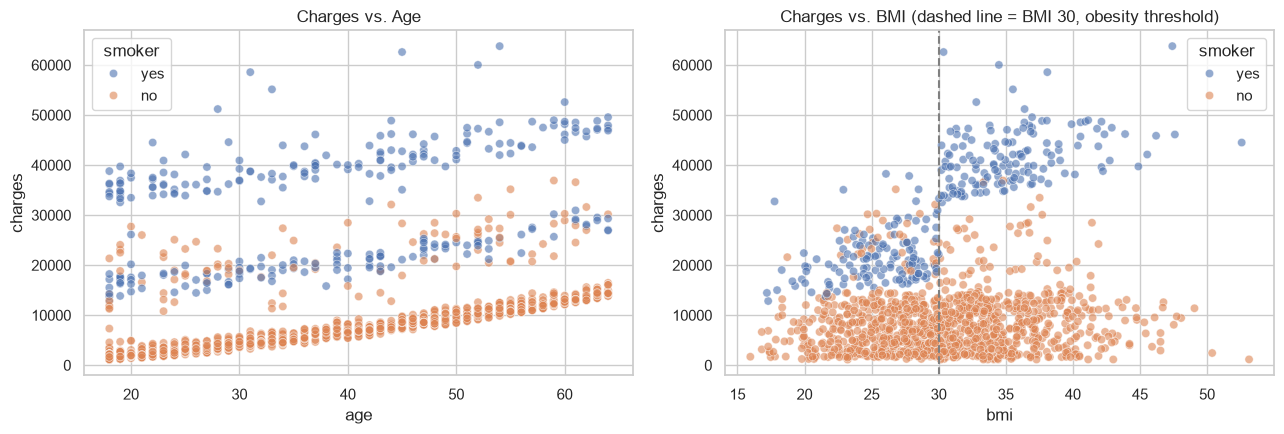

In [9]:
# Scatter plots of charges vs. age and BMI, coloured by smoker status
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.6, ax=axes[0])
axes[0].set_title("Charges vs. Age")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.6, ax=axes[1])
axes[1].axvline(30, color="grey", linestyle="--")
axes[1].set_title("Charges vs. BMI (dashed line = BMI 30, obesity threshold)")
plt.tight_layout()
plt.show()

**Rationale and interpretation:** Scatter plots show how the two main numeric predictors relate to charges, and colouring by smoker status reveals whether smoking changes those relationships. Charges rise steadily with age in three separate bands, and smokers sit in the upper bands. In the BMI plot, smokers with a BMI above 30 have much higher charges than smokers below 30, while non-smokers barely change, which suggests a smoker × obesity interaction worth adding to the model.

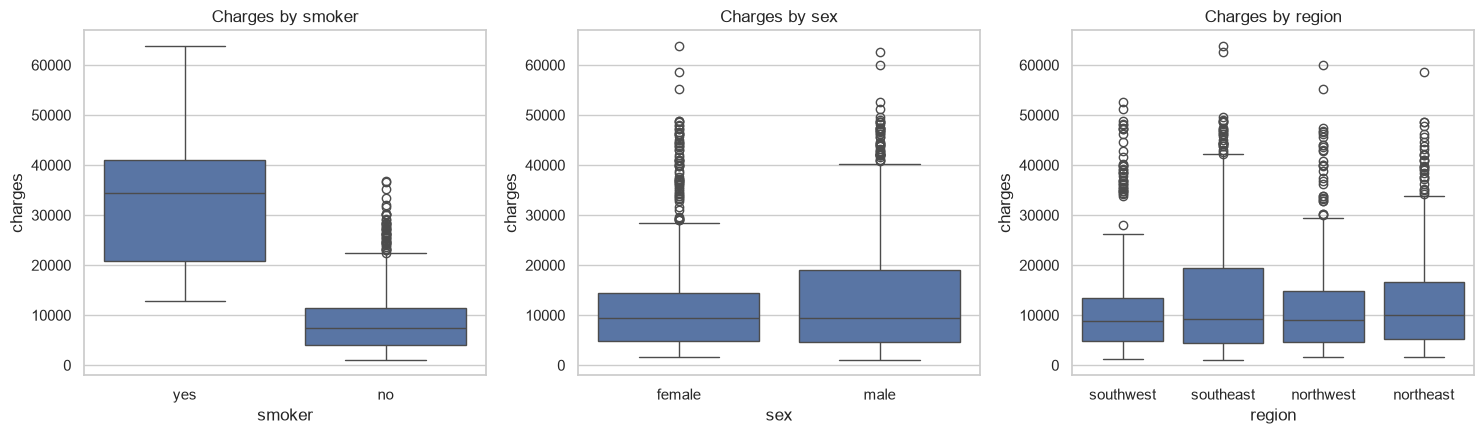

smoker
no      7346.0
yes    34456.0
Name: charges, dtype: float64


In [10]:
# Box plots of charges for each categorical variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["smoker", "sex", "region"]):
    sns.boxplot(data=df, x=col, y="charges", ax=ax)
    ax.set_title(f"Charges by {col}")
plt.tight_layout()
plt.show()
print(df.groupby("smoker")["charges"].median().round(0))

**Rationale and interpretation:** Box plots compare the distribution of charges across groups of a categorical variable. Smokers have a median charge of about \$34,500 compared with about \$7,300 for non-smokers, a nearly fivefold difference. Sex and region show very similar medians, so they are likely to be weak predictors.

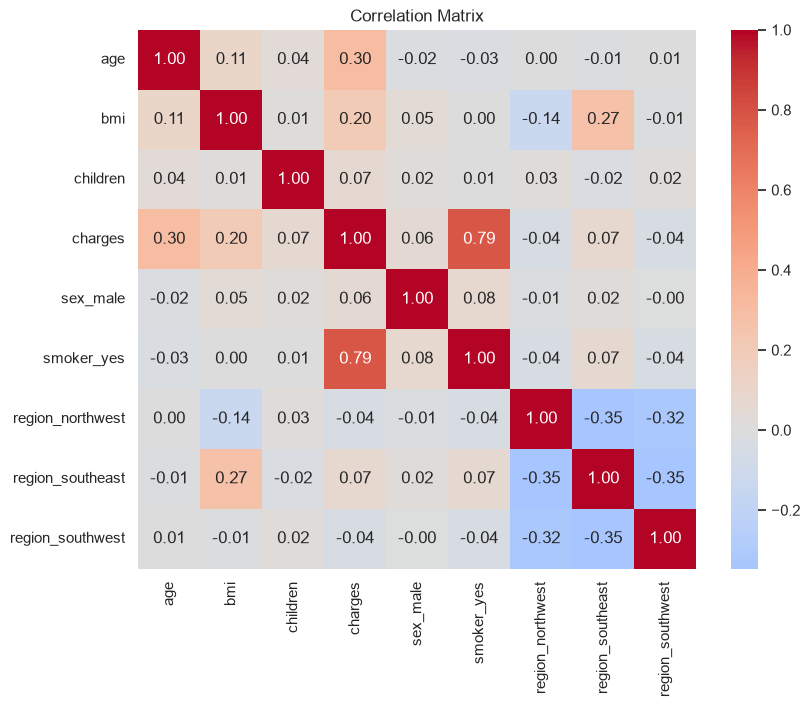

In [11]:
# Correlation heatmap (categorical variables converted to 0/1 first)
corr = pd.get_dummies(df, drop_first=True, dtype=int).corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

**Rationale and interpretation:** A heatmap summarizes all pairwise linear relationships at once and checks whether predictors are strongly correlated with each other (multicollinearity). Smoker status has by far the strongest correlation with charges (0.79), followed by age (0.30) and BMI (0.20). The predictors are only weakly correlated with each other, so multicollinearity is not a concern for linear regression.

## 4. Regression analysis

Based on the exploration, multiple linear regression is appropriate: the target is continuous, the relationships with age and BMI look roughly linear, and the categorical variables can be included as dummy variables. I compare three models on the same 80/20 train-test split:
1. **Baseline:** all six predictors as they are.
2. **Log model:** the same predictors with a log-transformed target, to address the skew.
3. **Improved model:** baseline plus an obesity flag (BMI ≥ 30), a smoker × obesity interaction, and age² (suggested by the scatter plots).

In [12]:
# Convert categorical variables to dummy (0/1) variables
data = pd.get_dummies(df, drop_first=True, dtype=int)

# Features for the improved model, based on patterns seen in the EDA
data["obese"] = (data["bmi"] >= 30).astype(int)            # BMI 30+ flag
data["smoker_obese"] = data["smoker_yes"] * data["obese"]   # smoker AND obese
data["age_sq"] = data["age"] ** 2                           # curve in the age trend

base_features = ["age", "bmi", "children", "sex_male", "smoker_yes",
                 "region_northwest", "region_southeast", "region_southwest"]
improved_features = base_features + ["obese", "smoker_obese", "age_sq"]

X = data[improved_features]
y = data["charges"]

# 80% training, 20% testing; random_state makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 1069 | Test rows: 268


In [13]:
# Helper function: report R², RMSE and MAE on the test set
def evaluate(name, y_true, y_pred):
    return {"Model": name,
            "R²": round(r2_score(y_true, y_pred), 3),
            "RMSE ($)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
            "MAE ($)": round(mean_absolute_error(y_true, y_pred), 0)}

results = []

# Model 1: baseline
m1 = LinearRegression().fit(X_train[base_features], y_train)
results.append(evaluate("1. Baseline", y_test, m1.predict(X_test[base_features])))

# Model 2: log-transformed target (predictions converted back to dollars with exp)
m2 = LinearRegression().fit(X_train[base_features], np.log(y_train))
results.append(evaluate("2. Log target", y_test, np.exp(m2.predict(X_test[base_features]))))

# Model 3: improved model with interaction terms
m3 = LinearRegression().fit(X_train[improved_features], y_train)
pred3 = m3.predict(X_test[improved_features])
results.append(evaluate("3. Improved (interactions)", y_test, pred3))

pd.DataFrame(results)

,Model,R²,RMSE ($),MAE ($)
0,1. Baseline,0.807,5956.0,4177.0
1,2. Log target,0.718,7198.0,3756.0
2,3. Improved (interactions),0.906,4158.0,2394.0


**Model comparison:** The baseline model explains about 81% of the variation in charges on unseen data. The log transform made results worse (R² ≈ 0.72), because it handles the skew but cannot capture the sharp jump for obese smokers. The improved model performs best, with R² ≈ 0.91 and RMSE ≈ \$4,160, so it is selected as the final model.

In [14]:
# Detailed statistical summary of the final model (statsmodels gives p-values)
ols = sm.OLS(y_train, sm.add_constant(X_train[improved_features])).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     554.0
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:03:50   Log-Likelihood:                -10509.
No. Observations:                1069   AIC:                         2.104e+04
Df Residuals:                    1057   BIC:                         2.110e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1843.4547   1558.816  

**Coefficient interpretation:** The most important term is `smoker_obese`: being both a smoker and obese adds roughly \$19,600 per year on top of the \$13,200 added by smoking alone, holding other variables constant. Age has a curved, positive effect on charges through the `age_sq` term. Sex and two of the three region dummies are not statistically significant (p > 0.05), which matches the box plots; only southwest shows a small negative effect (about −\$1,070). The warning about a large condition number comes from including both `age` and `age_sq`, which are naturally correlated, so it does not affect the predictions.

## 5. Model fit and residuals

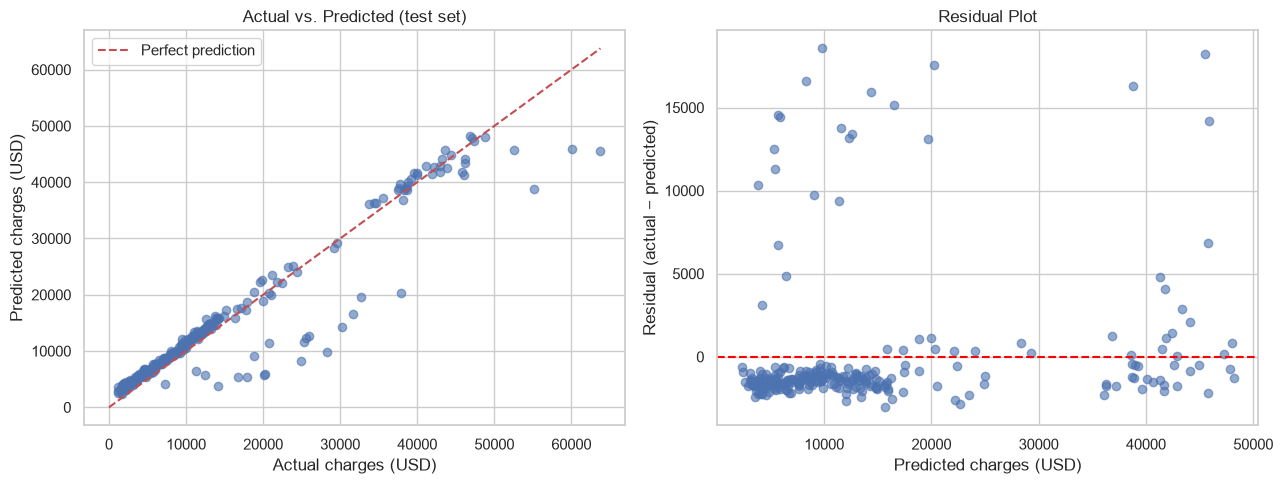

In [15]:
residuals = y_test - pred3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs. predicted: points near the red line are accurate predictions
axes[0].scatter(y_test, pred3, alpha=0.6)
lims = [0, max(y_test.max(), pred3.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual charges (USD)")
axes[0].set_ylabel("Predicted charges (USD)")
axes[0].set_title("Actual vs. Predicted (test set)")
axes[0].legend()

# Residuals vs. predicted: should be scattered randomly around zero
axes[1].scatter(pred3, residuals, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted charges (USD)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

**Rationale and interpretation:** The actual-vs-predicted plot shows overall fit, and the residual plot checks whether errors are random, which linear regression assumes. Most points lie close to the perfect-prediction line, and residuals are centred on zero. A small group of points has large positive residuals, meaning some people have unusually high charges the model cannot explain with the available variables, likely due to medical history that is not in the data.

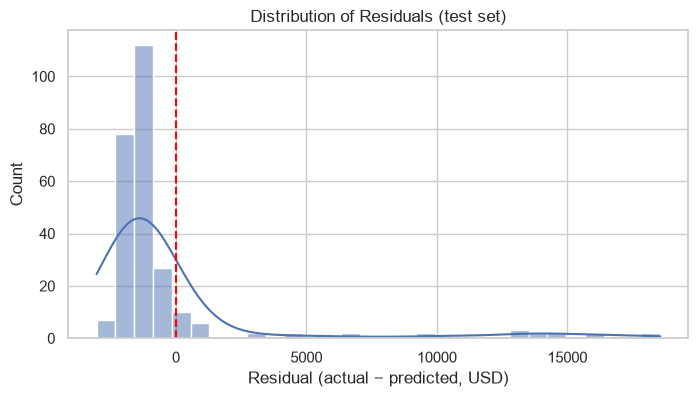

Mean residual: -49.0
Median residual: -1368.0
Share of residuals within ±$2,000: 80.2 %


In [16]:
# Histogram of residuals: checks whether errors are roughly normally distributed,
# an assumption of linear regression
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Residuals (test set)")
plt.xlabel("Residual (actual − predicted, USD)")
plt.show()
print("Mean residual:", round(residuals.mean(), 0))
print("Median residual:", round(residuals.median(), 0))
print("Share of residuals within ±$2,000:", round((residuals.abs() <= 2000).mean() * 100, 1), "%")

**Rationale and interpretation:** A histogram of residuals checks whether the model's errors are roughly normally distributed, which is an assumption of linear regression. The residuals are not normal: about 80% fall within ±\$2,000, mostly just below zero, but a long right tail shows a few people whose charges the model underestimates by \$10,000–\$18,000. This confirms the pattern in the residual plot and suggests that a factor not in the data, such as existing medical conditions, drives the highest costs, so the model is reliable for typical cases but less so for extreme ones.

## 6. Summary
The final multiple linear regression model predicts yearly insurance charges with R² ≈ 0.91 and RMSE ≈ \$4,160 on the test set. Smoking is the dominant driver of cost, especially combined with obesity, followed by age; sex and region have little effect.

**Reference:** Lantz, B. (2013). *Machine learning with R*. Packt Publishing. Data retrieved from https://github.com/stedy/Machine-Learning-with-R-datasets